# Códigos por sección — Capítulo 3: Los datos y su análisis

Este notebook reproduce las figuras del Capítulo 3 actual usando los datos `subject_S.zip` (NDBT2) y `subject_E.zip` (DBT2). No incluye código de Ackerman, Bergman ni Lotka–Volterra.

**Uso recomendado:** ejecutar las celdas en orden. Si se ejecuta una sección aislada, primero ejecutar siempre la celda inicial de configuración de rutas. Las figuras se guardan en la carpeta `figuras_cap3/` con resolución de 300 dpi.

**Observaciones importantes:**
- En `subject_E.zip` falta `subject_11_E.csv`; el código lo informa y continúa con los 19 sujetos DBT2 disponibles.
- La fórmula exacta de la ecuación (3.14) de `S(t)` no aparece visible en el DOCX. Se implementó `S(t)=v_c(t)·Ê(t)`, coherente con una ponderación multiplicativa por energía normalizada. Si la versión final usa `v_c(t)(1+Ê(t))`, basta cambiar `formula='vc_times_1_plus_Ehat'`.
- Para el ajuste espectral se expresan frecuencias en ciclos/día. El intervalo 0.01–0.4 indicado en el texto se implementa como 0.96–38.4 ciclos/día por el muestreo de 96 muestras/día.


In [1]:
from pathlib import Path
import sys

# Configuración robusta de rutas para que Jupyter encuentre common_cap3.py
# Funciona si abrís el notebook desde la carpeta del paquete o desde /mnt/data.
candidates = [
    Path.cwd(),
    Path.cwd() / 'codigos_capitulo3_jupyter',
    Path.cwd().parent,
    Path('/mnt/data/codigos_capitulo3_jupyter'),
]
BASE_DIR = None
for c in candidates:
    if (c / 'subject_S.zip').exists() and (c / 'subject_E.zip').exists():
        BASE_DIR = c.resolve()
        break
if BASE_DIR is None:
    BASE_DIR = Path.cwd().resolve()

SCRIPTS_DIR = BASE_DIR / 'scripts'
for ruta in [BASE_DIR, SCRIPTS_DIR]:
    if ruta.exists() and str(ruta) not in sys.path:
        sys.path.insert(0, str(ruta))

print('Directorio de trabajo Jupyter:', Path.cwd().resolve())
print('BASE_DIR datos/códigos:', BASE_DIR)
print('SCRIPTS_DIR:', SCRIPTS_DIR if SCRIPTS_DIR.exists() else 'No encontrado')


Directorio de trabajo Jupyter: C:\Users\aru_a\OneDrive\1.Doctorado\9.Tesis\Capítulo_3\Codigo
BASE_DIR datos/códigos: C:\Users\aru_a\OneDrive\1.Doctorado\9.Tesis\Capítulo_3\Codigo
SCRIPTS_DIR: C:\Users\aru_a\OneDrive\1.Doctorado\9.Tesis\Capítulo_3\Codigo\scripts


## Funciones comunes

In [2]:
"""
Funciones comunes para reproducir las figuras del Capítulo 3.
Datos esperados:
    - subject_S.zip: sujetos NDBT2 / sanos
    - subject_E.zip: sujetos DBT2 / enfermos
Cada CSV debe contener una columna llamada 'Glucosa'.
"""

from __future__ import annotations

import itertools
import os
import re
import zipfile
from pathlib import Path
from typing import Dict, Tuple, List

import numpy as np
import pandas as pd
from scipy.signal import savgol_filter, welch
from scipy.fft import dct, idct
from scipy.spatial import cKDTree
from scipy.stats import linregress, ttest_ind
from sklearn.metrics import mutual_info_score

DT_MIN = 15
DT_HOURS = DT_MIN / 60
FS_PER_DAY = int(24 * 60 / DT_MIN)  # 96 muestras/día
N_12_DAYS = 12 * FS_PER_DAY         # 1152 muestras


def _natural_subject_number(path: Path) -> int:
    match = re.search(r"subject_(\d+)_", path.name)
    return int(match.group(1)) if match else 10**9


def extract_zip_if_needed(zip_path: str | Path, out_dir: str | Path) -> Path:
    zip_path = Path(zip_path)
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    if not any(out_dir.glob("*.csv")):
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(out_dir)
    return out_dir


def load_subjects(
    s_zip: str | Path = "subject_S.zip",
    e_zip: str | Path = "subject_E.zip",
    base_dir: str | Path = ".",
    n_points: int | None = N_12_DAYS,
) -> Dict[str, Dict[int, np.ndarray]]:
    """Carga sujetos desde los ZIP y devuelve {'NDBT2': {id: G}, 'DBT2': {id: G}}."""
    base_dir = Path(base_dir)
    s_dir = extract_zip_if_needed(base_dir / s_zip, base_dir / "subject_S")
    e_dir = extract_zip_if_needed(base_dir / e_zip, base_dir / "subject_E")

    out = {"NDBT2": {}, "DBT2": {}}
    for group, folder, suffix in [("NDBT2", s_dir, "S"), ("DBT2", e_dir, "E")]:
        for csv_path in sorted(folder.glob(f"subject_*_{suffix}.csv"), key=_natural_subject_number):
            sid = _natural_subject_number(csv_path)
            df = pd.read_csv(csv_path)
            if "Glucosa" not in df.columns:
                raise ValueError(f"{csv_path.name} no tiene columna 'Glucosa'. Columnas: {df.columns.tolist()}")
            g = pd.to_numeric(df["Glucosa"], errors="coerce").dropna().to_numpy(dtype=float)
            if n_points is not None:
                g = g[:n_points]
            out[group][sid] = g
    return out


def time_axis(n: int, unit: str = "days") -> np.ndarray:
    minutes = np.arange(n) * DT_MIN
    if unit == "minutes":
        return minutes
    if unit == "hours":
        return minutes / 60
    if unit == "days":
        return minutes / (60 * 24)
    raise ValueError("unit debe ser 'minutes', 'hours' o 'days'.")


def day_slice(day: int, start_hour: float = 0, end_hour: float = 24) -> slice:
    start = day * FS_PER_DAY + int(round(start_hour / DT_HOURS))
    end = day * FS_PER_DAY + int(round(end_hour / DT_HOURS))
    return slice(start, end)


def savgol_trend(g: np.ndarray, window: int = 51, polyorder: int = 3) -> np.ndarray:
    g = np.asarray(g, dtype=float)
    window = min(window, len(g) if len(g) % 2 == 1 else len(g) - 1)
    if window < polyorder + 2:
        return pd.Series(g).rolling(5, center=True, min_periods=1).mean().to_numpy()
    if window % 2 == 0:
        window += 1
    return savgol_filter(g, window_length=window, polyorder=polyorder, mode="interp")


def colored_noise_beta(
    signal: np.ndarray,
    fs: float = FS_PER_DAY,
    nperseg: int = 256,
    fit_range: Tuple[float, float] = (0.5, 12.0),
) -> Tuple[float, np.ndarray, np.ndarray, Tuple[float, float, float]]:
    """Estima beta de P(f) ~ 1/f^beta por Welch y ajuste log-log.

    fs se expresa en muestras por día; por lo tanto f queda en ciclos/día.
    """
    x = np.asarray(signal, dtype=float)
    nperseg = min(nperseg, len(x))
    f, pxx = welch(x, fs=fs, nperseg=nperseg, noverlap=nperseg // 2, detrend="constant")
    mask = (f > 0) & np.isfinite(pxx) & (pxx > 0) & (f >= fit_range[0]) & (f <= fit_range[1])
    if mask.sum() < 3:
        return np.nan, f, pxx, (np.nan, np.nan, np.nan)
    slope, intercept, r, pvalue, stderr = linregress(np.log10(f[mask]), np.log10(pxx[mask]))
    beta = -slope
    return beta, f, pxx, (slope, intercept, r)


def dfa_alpha(
    x: np.ndarray,
    scales: np.ndarray | None = None,
    order: int = 1,
) -> Tuple[float, np.ndarray, np.ndarray, Tuple[float, float, float]]:
    """Detrended Fluctuation Analysis de orden polinómico dado."""
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    y = np.cumsum(x - np.mean(x))
    n = len(y)
    if scales is None:
        scales = np.unique(np.logspace(np.log10(8), np.log10(min(288, n // 4)), 24).astype(int))
    Fs = []
    valid_scales = []
    for s in scales:
        s = int(s)
        if s <= order + 2 or n // s < 4:
            continue
        nseg = n // s
        rms_vals = []
        for v in range(nseg):
            seg = y[v * s:(v + 1) * s]
            t = np.arange(s)
            coeff = np.polyfit(t, seg, order)
            trend = np.polyval(coeff, t)
            rms_vals.append(np.sqrt(np.mean((seg - trend) ** 2)))
        F = np.sqrt(np.mean(np.asarray(rms_vals) ** 2))
        if np.isfinite(F) and F > 0:
            Fs.append(F)
            valid_scales.append(s)
    valid_scales = np.asarray(valid_scales, dtype=float)
    Fs = np.asarray(Fs, dtype=float)
    if len(Fs) < 3:
        return np.nan, valid_scales, Fs, (np.nan, np.nan, np.nan)
    slope, intercept, r, pvalue, stderr = linregress(np.log10(valid_scales), np.log10(Fs))
    return slope, valid_scales, Fs, (slope, intercept, r)


def centered_velocity(g: np.ndarray, dt_min: float = DT_MIN) -> np.ndarray:
    g = np.asarray(g, dtype=float)
    v = np.empty_like(g, dtype=float)
    if len(g) < 3:
        return np.zeros_like(g, dtype=float)
    v[1:-1] = (g[2:] - g[:-2]) / (2 * dt_min)
    v[0] = (g[1] - g[0]) / dt_min
    v[-1] = (g[-1] - g[-2]) / dt_min
    return v


def conditioned_velocity(v: np.ndarray, kappa: float = 1.0) -> np.ndarray:
    v = np.asarray(v, dtype=float)
    sigma_v = np.nanstd(v)
    if sigma_v == 0 or not np.isfinite(sigma_v):
        return np.zeros_like(v)
    return sigma_v * np.tanh(kappa * v / sigma_v)


def local_energy(g: np.ndarray, window: int = 10) -> np.ndarray:
    s = pd.Series(np.asarray(g, dtype=float))
    return s.rolling(window=window, center=True, min_periods=2).var(ddof=0).bfill().ffill().to_numpy()


def dct_smooth_energy(e: np.ndarray, keep_fraction: float = 0.10) -> np.ndarray:
    e = np.asarray(e, dtype=float)
    coeff = dct(e, norm="ortho")
    keep = max(1, int(np.ceil(len(coeff) * keep_fraction)))
    filt = np.zeros_like(coeff)
    filt[:keep] = coeff[:keep]
    out = idct(filt, norm="ortho")
    return np.maximum(out, 0)


def metabolic_force(
    g: np.ndarray,
    window_energy: int = 10,
    keep_fraction: float = 0.10,
    kappa: float = 1.0,
    formula: str = "vc_times_Ehat",
) -> Dict[str, np.ndarray]:
    """Construye v(t), v_c(t), E(t), E_suav(t), E_hat(t) y S(t).

    formula='vc_times_Ehat' implementa S(t)=v_c(t)*E_hat(t), consistente con
    una ponderación por volatilidad acotada entre 0 y 1.
    Si el manuscrito final decide usar ganancia adaptativa, puede cambiarse a
    formula='vc_times_1_plus_Ehat', que implementa S(t)=v_c(t)*(1+E_hat(t)).
    """
    v = centered_velocity(g)
    vc = conditioned_velocity(v, kappa=kappa)
    e = local_energy(g, window=window_energy)
    e_s = dct_smooth_energy(e, keep_fraction=keep_fraction)
    denom = np.nanmax(e_s)
    e_hat = e_s / denom if denom and np.isfinite(denom) else np.zeros_like(e_s)
    if formula == "vc_times_Ehat":
        S = vc * e_hat
    elif formula == "vc_times_1_plus_Ehat":
        S = vc * (1 + e_hat)
    else:
        raise ValueError("formula debe ser 'vc_times_Ehat' o 'vc_times_1_plus_Ehat'.")
    return {"v": v, "vc": vc, "E": e, "E_smooth": e_s, "E_hat": e_hat, "S": S}


def morlet_band_energy(
    x: np.ndarray,
    period_hours: Tuple[float, float],
    n_periods: int = 24,
    w0: float = 6.0,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Energía tipo CWT-Morlet promediada en una banda de períodos.

    Implementación sin PyWavelets para facilitar uso en Jupyter estándar.
    Devuelve energía normalizada, matriz |coef|^2 y períodos en horas.
    """
    x = np.asarray(x, dtype=float)
    x0 = x - np.nanmean(x)
    periods_h = np.linspace(period_hours[0], period_hours[1], n_periods)
    powers = []
    for ph in periods_h:
        period_samples = ph / DT_HOURS
        scale = max(1.0, period_samples * w0 / (2 * np.pi))
        half = int(np.ceil(4 * scale))
        t = np.arange(-half, half + 1)
        wave = np.exp(1j * w0 * t / scale) * np.exp(-(t ** 2) / (2 * scale ** 2))
        wave -= wave.mean()
        norm = np.sqrt(np.sum(np.abs(wave) ** 2))
        if norm > 0:
            wave = wave / norm
        coef = np.convolve(x0, np.conj(wave[::-1]), mode="same")
        powers.append(np.abs(coef) ** 2)
    power = np.vstack(powers)
    band = np.nanmean(power, axis=0)
    if np.nanmax(band) > 0:
        band = band / np.nanmax(band)
    return band, power, periods_h


def positive_negative_areas(x: np.ndarray, dt_hours: float = DT_HOURS) -> Tuple[float, float, float]:
    x = np.asarray(x, dtype=float)
    pos = np.maximum(x, 0)
    neg = np.maximum(-x, 0)
    a_pos = np.nansum(pos) * dt_hours
    a_neg = np.nansum(neg) * dt_hours
    eps = 1e-12
    idx = (a_pos - a_neg) / (a_pos + a_neg + eps)
    return a_pos, a_neg, idx


def classify_event(delta_g: float, I_G: float, I_S: float, W: float, kind: str) -> str:
    if delta_g <= 0 or (I_G <= 0 and I_S <= 0):
        return "No compatible"
    if kind == "alba":
        if delta_g >= 50 and I_G > 0 and I_S > 0 and W >= 0.35:
            return "Fuerte"
        if delta_g >= 30 and (I_G > 0 or I_S > 0) and W >= 0.20:
            return "Moderada"
        return "Posible"
    if kind == "ingesta":
        if delta_g >= 120 and I_G > 0 and I_S > 0 and W >= 0.35:
            return "Fuerte"
        if delta_g >= 60 and I_S > 0 and W >= 0.20:
            return "Moderada"
        if delta_g >= 20 and (I_G > 0 or I_S > 0):
            return "Posible"
        return "No compatible"
    raise ValueError("kind debe ser 'alba' o 'ingesta'.")


def detect_dawn(g: np.ndarray, S: np.ndarray) -> pd.DataFrame:
    slow_energy, _, _ = morlet_band_energy(S, (3.0, 8.0))
    rows = []
    ndays = len(g) // FS_PER_DAY
    for day in range(ndays):
        sl = day_slice(day, 3, 8)
        gw = g[sl]
        sw = S[sl]
        ww = slow_energy[sl]
        if len(gw) == 0:
            continue
        delta_g = float(gw[-1] - gw[0])
        _, _, I_G = positive_negative_areas(gw - gw[0])
        _, _, I_S = positive_negative_areas(sw)
        W = float(np.nanmean(ww))
        rows.append({
            "dia": day + 1,
            "inicio_h": 3.0,
            "fin_h": 8.0,
            "DeltaG": delta_g,
            "I_G": I_G,
            "I_S": I_S,
            "W_lenta": W,
            "clasificacion": classify_event(delta_g, I_G, I_S, W, "alba"),
        })
    return pd.DataFrame(rows)


def detect_meal_like_events(
    g: np.ndarray,
    S: np.ndarray,
    window_samples: int = 10,
    min_delta_g: float = 20,
    min_score: float = 0.0,
) -> pd.DataFrame:
    fast_energy, _, _ = morlet_band_energy(S, (0.5, 2.0))
    candidates = []
    ndays = len(g) // FS_PER_DAY
    for day in range(ndays):
        day0 = day * FS_PER_DAY
        start_min = day0 + int(round(8 / DT_HOURS))
        start_max = day0 + int(round(21.5 / DT_HOURS))
        for start in range(start_min, min(start_max, day0 + FS_PER_DAY - window_samples) + 1):
            end = start + window_samples
            gw = g[start:end]
            sw = S[start:end]
            ww = fast_energy[start:end]
            delta_g = float(np.nanmax(gw - gw[0]))
            if delta_g < min_delta_g:
                continue
            _, _, I_G = positive_negative_areas(gw - gw[0])
            _, _, I_S = positive_negative_areas(sw)
            W = float(np.nanmean(ww))
            score = delta_g * max(I_G, 0) * max(I_S, 0) * (0.5 + W)
            if score <= min_score:
                continue
            label = classify_event(delta_g, I_G, I_S, W, "ingesta")
            if label == "No compatible":
                continue
            candidates.append({
                "dia": day + 1,
                "inicio_idx": start,
                "fin_idx": end,
                "inicio_h": (start - day0) * DT_HOURS,
                "fin_h": (end - day0) * DT_HOURS,
                "DeltaGmax": delta_g,
                "I_G": I_G,
                "I_S": I_S,
                "W_rapida": W,
                "score": score,
                "clasificacion": label,
            })
    # Selección greedy de ventanas no solapadas por día y por puntaje.
    selected = []
    for day in range(1, ndays + 1):
        day_cands = [c for c in candidates if c["dia"] == day]
        day_cands = sorted(day_cands, key=lambda r: r["score"], reverse=True)
        accepted = []
        for c in day_cands:
            overlaps = any(not (c["fin_idx"] <= a["inicio_idx"] or c["inicio_idx"] >= a["fin_idx"]) for a in accepted)
            if not overlaps:
                accepted.append(c)
        selected.extend(sorted(accepted, key=lambda r: r["inicio_idx"]))
    return pd.DataFrame(selected)


def ordinal_patterns(x: np.ndarray, D: int = 3, tau: int = 1) -> Tuple[np.ndarray, List[Tuple[int, ...]]]:
    x = np.asarray(x, dtype=float)
    perms = list(itertools.permutations(range(D)))
    perm_to_id = {p: i for i, p in enumerate(perms)}
    n = len(x) - (D - 1) * tau
    ids = []
    for t in range(max(0, n)):
        window = x[t:t + D * tau:tau]
        # mergesort es estable: conserva orden temporal ante empates.
        pattern = tuple(np.argsort(window, kind="mergesort"))
        ids.append(perm_to_id[pattern])
    return np.asarray(ids, dtype=int), perms


def permutation_distribution(x: np.ndarray, D: int = 3, tau: int = 1) -> np.ndarray:
    ids, perms = ordinal_patterns(x, D=D, tau=tau)
    counts = np.bincount(ids, minlength=len(perms)).astype(float)
    total = counts.sum()
    return counts / total if total > 0 else np.ones(len(perms)) / len(perms)


def shannon_entropy(p: np.ndarray) -> float:
    p = np.asarray(p, dtype=float)
    p = p[p > 0]
    return float(-np.sum(p * np.log(p)))


def h_complexity(p: np.ndarray) -> Tuple[float, float]:
    p = np.asarray(p, dtype=float)
    M = len(p)
    pe = np.ones(M) / M
    H = shannon_entropy(p) / np.log(M)
    js = shannon_entropy((p + pe) / 2) - 0.5 * shannon_entropy(p) - 0.5 * shannon_entropy(pe)
    delta = np.zeros(M); delta[0] = 1.0
    js_max = shannon_entropy((delta + pe) / 2) - 0.5 * shannon_entropy(delta) - 0.5 * shannon_entropy(pe)
    C = (js / js_max) * H if js_max > 0 else np.nan
    return H, C


def hx_c_bounds(M: int = 6, n_random: int = 25000, seed: int = 123) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Aproximación Monte Carlo de Cmin y Cmax para graficar la región accesible."""
    rng = np.random.default_rng(seed)
    Ps = rng.dirichlet(np.ones(M), size=n_random)
    HC = np.array([h_complexity(p) for p in Ps])
    H, C = HC[:, 0], HC[:, 1]
    bins = np.linspace(0, 1, 80)
    centers = 0.5 * (bins[:-1] + bins[1:])
    cmin = np.full(len(centers), np.nan)
    cmax = np.full(len(centers), np.nan)
    for i in range(len(centers)):
        m = (H >= bins[i]) & (H < bins[i + 1])
        if np.any(m):
            cmin[i] = np.nanmin(C[m])
            cmax[i] = np.nanmax(C[m])
    return centers, cmin, cmax


def optm_stationary_indicator(x: np.ndarray, D: int = 3, tau: int = 1) -> Tuple[float, np.ndarray, np.ndarray]:
    ids, perms = ordinal_patterns(x, D=D, tau=tau)
    M = len(perms)
    counts = np.zeros((M, M), dtype=float)
    for a, b in zip(ids[:-1], ids[1:]):
        counts[a, b] += 1
    row_sums = counts.sum(axis=1, keepdims=True)
    P = np.divide(counts, row_sums, out=np.ones_like(counts) / M, where=row_sums > 0)
    # vector estacionario: autovector izquierdo para autovalor 1
    w, v = np.linalg.eig(P.T)
    idx = np.argmin(np.abs(w - 1))
    stat = np.real(v[:, idx])
    stat = np.abs(stat)
    stat = stat / stat.sum() if stat.sum() > 0 else np.ones(M) / M
    return float(np.linalg.norm(stat)), P, stat


def classify_stat_ms(value: float, sane_max: float = 0.49, diabetic_min: float = 0.505) -> str:
    if value < sane_max:
        return "Sano"
    if value >= diabetic_min:
        return "Diabetes"
    return "Dudoso"


def delay_embed(x: np.ndarray, m: int = 4, tau: int = 4) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    n = len(x) - (m - 1) * tau
    if n <= 0:
        raise ValueError("Serie demasiado corta para ese m y tau.")
    return np.column_stack([x[i * tau:i * tau + n] for i in range(m)])


def lyapunov_rosenstein(
    x: np.ndarray,
    m: int = 4,
    tau: int = 4,
    min_tsep: int = FS_PER_DAY,
    max_k: int = 40,
    fit_k: Tuple[int, int] = (1, 12),
) -> Tuple[float, float, np.ndarray, np.ndarray]:
    """Estimador tipo Rosenstein. Devuelve lambda en h^-1 y tiempo Lyapunov en h."""
    X = delay_embed(x, m=m, tau=tau)
    N = len(X)
    tree = cKDTree(X)
    neigh = np.full(N, -1, dtype=int)
    for i in range(N):
        k = 2
        while True:
            dists, idxs = tree.query(X[i], k=min(k, N))
            idxs = np.atleast_1d(idxs)
            valid = idxs[np.abs(idxs - i) >= min_tsep]
            if len(valid) > 0:
                neigh[i] = valid[0]
                break
            k *= 2
            if k > N:
                break
    ks = np.arange(max_k + 1)
    log_div = []
    eps = 1e-12
    for kk in ks:
        vals = []
        for i, j in enumerate(neigh):
            if j < 0:
                continue
            if i + kk < N and j + kk < N:
                d = np.linalg.norm(X[i + kk] - X[j + kk])
                if d > eps and np.isfinite(d):
                    vals.append(np.log(d))
        log_div.append(np.nanmean(vals) if vals else np.nan)
    log_div = np.asarray(log_div, dtype=float)
    a, b = fit_k
    mask = (ks >= a) & (ks <= b) & np.isfinite(log_div)
    if mask.sum() < 3:
        return np.nan, np.nan, ks * DT_HOURS, log_div
    slope, intercept, r, pvalue, stderr = linregress(ks[mask] * DT_HOURS, log_div[mask])
    lam_h = slope
    T_L = 1 / lam_h if lam_h > 0 else np.inf
    return float(lam_h), float(T_L), ks * DT_HOURS, log_div


def quantile_binning(x: np.ndarray, n_bins: int = 16) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    qs = np.unique(np.quantile(x, np.linspace(0, 1, n_bins + 1)))
    if len(qs) <= 2:
        return np.zeros_like(x, dtype=int)
    return np.digitize(x, qs[1:-1], right=False)


def average_mutual_information(x: np.ndarray, max_lag: int = 32, n_bins: int = 16) -> Tuple[np.ndarray, np.ndarray]:
    xb = quantile_binning(x, n_bins=n_bins)
    amis = []
    lags = np.arange(1, max_lag + 1)
    for lag in lags:
        amis.append(mutual_info_score(xb[:-lag], xb[lag:]))
    amis = np.asarray(amis, dtype=float)
    if np.nanmax(amis) > 0:
        amis = amis / np.nanmax(amis)
    return lags, amis


def false_nearest_neighbors(
    x: np.ndarray,
    tau: int = 4,
    max_m: int = 8,
    rtol: float = 10.0,
    atol: float = 2.0,
) -> Tuple[np.ndarray, np.ndarray]:
    x = np.asarray(x, dtype=float)
    std_x = np.nanstd(x)
    ms, fnn = [], []
    for m in range(1, max_m + 1):
        Xm = delay_embed(x, m=m, tau=tau)
        Xm1 = delay_embed(x, m=m + 1, tau=tau)
        N = min(len(Xm), len(Xm1))
        Xm = Xm[:N]
        Xm1 = Xm1[:N]
        tree = cKDTree(Xm)
        dists, idxs = tree.query(Xm, k=2)
        nn = idxs[:, 1]
        dist_m = dists[:, 1]
        dist_m = np.maximum(dist_m, 1e-12)
        extra = np.abs(Xm1[:, -1] - Xm1[nn, -1])
        dist_m1 = np.linalg.norm(Xm1 - Xm1[nn], axis=1)
        false = (extra / dist_m > rtol) | (dist_m1 / std_x > atol)
        ms.append(m)
        fnn.append(100 * np.mean(false))
    return np.asarray(ms), np.asarray(fnn)


## 00 configuracion y carga datos

In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
from common_cap3 import load_subjects, N_12_DAYS

BASE_DIR = Path('.').resolve()
subjects = load_subjects(base_dir=BASE_DIR, n_points=N_12_DAYS)

print('Sujetos NDBT2 cargados:', sorted(subjects['NDBT2']))
print('Sujetos DBT2 cargados:', sorted(subjects['DBT2']))

faltantes_dbt2 = sorted(set(range(1, 21)) - set(subjects['DBT2']))
faltantes_ndbt2 = sorted(set(range(1, 21)) - set(subjects['NDBT2']))
if faltantes_dbt2:
    print('Faltan archivos DBT2:', faltantes_dbt2)
if faltantes_ndbt2:
    print('Faltan archivos NDBT2:', faltantes_ndbt2)

resumen = []
for grupo, data in subjects.items():
    for sid, g in data.items():
        resumen.append({
            'grupo': grupo,
            'sujeto': sid,
            'n_muestras': len(g),
            'media_glucosa': np.mean(g),
            'min_glucosa': np.min(g),
            'max_glucosa': np.max(g),
        })
resumen = pd.DataFrame(resumen)
print(resumen.head())


Sujetos NDBT2 cargados: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Sujetos DBT2 cargados: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Faltan archivos DBT2: [11]
   grupo  sujeto  n_muestras  media_glucosa  min_glucosa  max_glucosa
0  NDBT2       1        1152      84.698785         53.0        141.0
1  NDBT2       2        1152      76.683160         40.0        146.0
2  NDBT2       3        1152      89.842882         42.0        171.0
3  NDBT2       4        1152     106.270833         53.0        196.0
4  NDBT2       5        1152     100.039062         62.0        197.0


## 3 1 figura 3 registros 24h

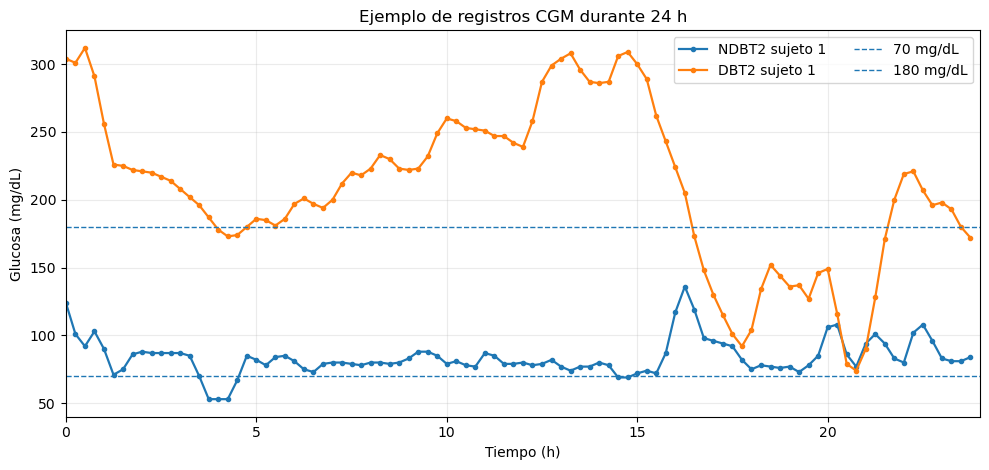

In [4]:
from pathlib import Path
import matplotlib.pyplot as plt
from common_cap3 import load_subjects, day_slice, time_axis, N_12_DAYS

BASE_DIR = Path('.').resolve()
OUT_DIR = BASE_DIR / 'figuras_cap3'
OUT_DIR.mkdir(exist_ok=True)
subjects = load_subjects(base_dir=BASE_DIR, n_points=N_12_DAYS)

# Figura 3: ejemplo de 24 h. Cambiar estos valores si en el documento se usaron otros sujetos/días.
sujeto_ndbt2 = 1
sujeto_dbt2 = 1
dia = 0

G_s = subjects['NDBT2'][sujeto_ndbt2][day_slice(dia, 0, 24)]
G_e = subjects['DBT2'][sujeto_dbt2][day_slice(dia, 0, 24)]
t = time_axis(len(G_s), unit='hours')

plt.figure(figsize=(10, 4.8))
plt.plot(t, G_s, marker='o', markersize=3, linewidth=1.6, label=f'NDBT2 sujeto {sujeto_ndbt2}')
plt.plot(t, G_e, marker='o', markersize=3, linewidth=1.6, label=f'DBT2 sujeto {sujeto_dbt2}')
plt.axhline(70, linestyle='--', linewidth=1, label='70 mg/dL')
plt.axhline(180, linestyle='--', linewidth=1, label='180 mg/dL')
plt.xlabel('Tiempo (h)')
plt.ylabel('Glucosa (mg/dL)')
plt.title('Ejemplo de registros CGM durante 24 h')
plt.xlim(0, 24)
plt.grid(alpha=0.25)
plt.legend(ncol=2)
plt.tight_layout()
plt.savefig(OUT_DIR / 'figura_3_registros_24h.png', dpi=300)
plt.show()


## 3 1 2 descomposicion espectral beta

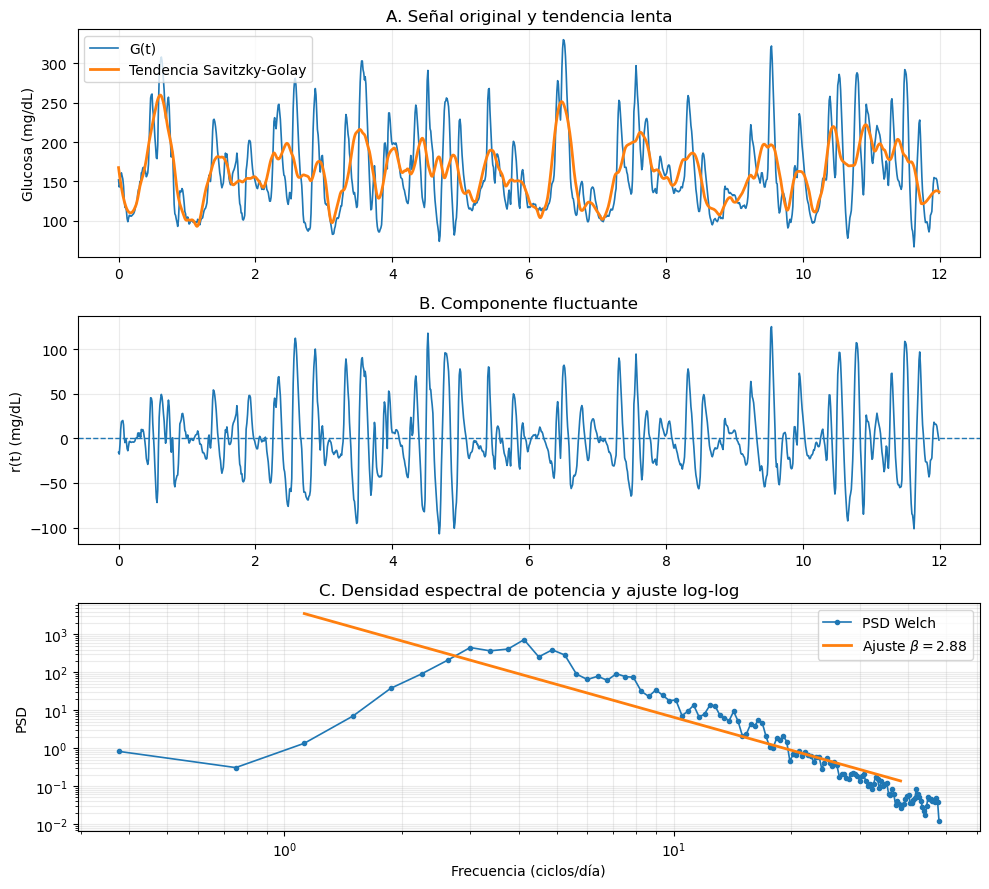

beta estimado para DBT2 sujeto 5: 2.8833


In [5]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from common_cap3 import load_subjects, savgol_trend, colored_noise_beta, time_axis, N_12_DAYS

BASE_DIR = Path('.').resolve()
OUT_DIR = BASE_DIR / 'figuras_cap3'
OUT_DIR.mkdir(exist_ok=True)
subjects = load_subjects(base_dir=BASE_DIR, n_points=N_12_DAYS)

# Ejemplo para la descomposición espectral. Cambiar grupo/sujeto si la figura del documento usó otro caso.
grupo = 'DBT2'
sujeto = 5
G = subjects[grupo][sujeto]
t = time_axis(len(G), unit='days')
trend = savgol_trend(G, window=51, polyorder=3)
r = G - trend
# El texto indica 0.01-0.4; con muestreo de 96 muestras/día equivale a 0.96-38.4 ciclos/día.
beta, f, pxx, fit = colored_noise_beta(r, fit_range=(0.96, 38.4))
slope, intercept, _ = fit

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=False)
axes[0].plot(t, G, linewidth=1.2, label='G(t)')
axes[0].plot(t, trend, linewidth=2.0, label='Tendencia Savitzky-Golay')
axes[0].set_ylabel('Glucosa (mg/dL)')
axes[0].set_title('A. Señal original y tendencia lenta')
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(t, r, linewidth=1.2)
axes[1].axhline(0, linestyle='--', linewidth=1)
axes[1].set_ylabel('r(t) (mg/dL)')
axes[1].set_title('B. Componente fluctuante')
axes[1].grid(alpha=0.25)

mask = (f > 0) & (pxx > 0)
axes[2].loglog(f[mask], pxx[mask], marker='o', markersize=3, linewidth=1.2, label='PSD Welch')
fit_mask = (f >= 0.96) & (f <= 38.4) & mask
if fit_mask.sum() >= 3:
    axes[2].loglog(f[fit_mask], 10 ** (intercept + slope * np.log10(f[fit_mask])), linewidth=2.0,
                   label=fr'Ajuste $\beta={beta:.2f}$')
axes[2].set_xlabel('Frecuencia (ciclos/día)')
axes[2].set_ylabel('PSD')
axes[2].set_title('C. Densidad espectral de potencia y ajuste log-log')
axes[2].grid(alpha=0.25, which='both')
axes[2].legend()

plt.tight_layout()
plt.savefig(OUT_DIR / 'figura_3_1_2_descomposicion_espectral_beta.png', dpi=300)
plt.show()
print(f'beta estimado para {grupo} sujeto {sujeto}: {beta:.4f}')


## 3 1 3 comparacion ruido coloreado

    grupo  sujeto      beta
0   NDBT2       1  1.375791
1   NDBT2       2  1.287254
2   NDBT2       3  1.181293
3   NDBT2       4  1.209117
4   NDBT2       5  1.518453
5   NDBT2       6  1.265288
6   NDBT2       7  1.214162
7   NDBT2       8  1.306609
8   NDBT2       9  1.317612
9   NDBT2      10  1.188628
10  NDBT2      11  1.521306
11  NDBT2      12  1.240454
12  NDBT2      13  1.174307
13  NDBT2      14  1.212759
14  NDBT2      15  1.247724
15  NDBT2      16  1.187966
16  NDBT2      17  1.151864
17  NDBT2      18  1.246116
18  NDBT2      19  1.334429
19  NDBT2      20  1.368545
20   DBT2       1  2.740082
21   DBT2       2  2.180061
22   DBT2       3  2.049771
23   DBT2       4  2.390747
24   DBT2       5  2.883270
25   DBT2       6  2.390747
26   DBT2       7  2.274001
27   DBT2       8  2.116565
28   DBT2       9  2.280970
29   DBT2      10  2.084037
30   DBT2      12  1.460468
31   DBT2      13  1.799677
32   DBT2      14  2.135701
33   DBT2      15  1.988953
34   DBT2      16  2

C:\Users\aru_a\AppData\Local\Temp\ipykernel_26116\1448860474.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([b_s, b_e], positions=positions, labels=['NDBT2', 'DBT2'], showmeans=True)


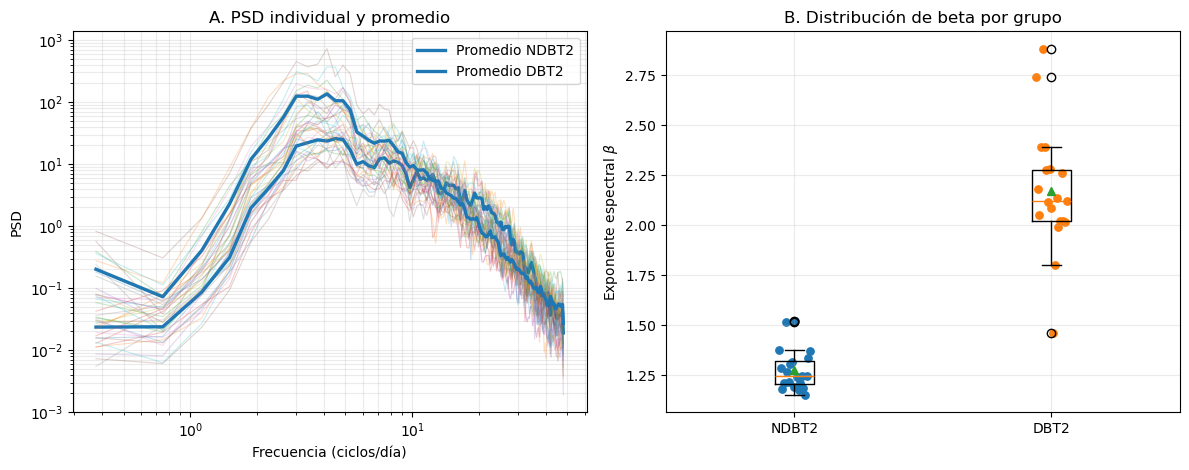

In [6]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from common_cap3 import load_subjects, savgol_trend, colored_noise_beta, N_12_DAYS

BASE_DIR = Path('.').resolve()
OUT_DIR = BASE_DIR / 'figuras_cap3'
OUT_DIR.mkdir(exist_ok=True)
subjects = load_subjects(base_dir=BASE_DIR, n_points=N_12_DAYS)

rows = []
psd_data = {'NDBT2': [], 'DBT2': []}
for grupo, data in subjects.items():
    for sid, G in data.items():
        r = G - savgol_trend(G, window=51, polyorder=3)
        # Rango equivalente al 0.01-0.4 indicado en el texto, expresado en ciclos/día.
        beta, f, pxx, _ = colored_noise_beta(r, fit_range=(0.96, 38.4))
        rows.append({'grupo': grupo, 'sujeto': sid, 'beta': beta})
        psd_data[grupo].append((f, pxx))
res = pd.DataFrame(rows)
print(res)

b_s = res.loc[res.grupo == 'NDBT2', 'beta'].dropna()
b_e = res.loc[res.grupo == 'DBT2', 'beta'].dropna()
stat, pval = ttest_ind(b_e, b_s, equal_var=False, nan_policy='omit')
print(f'Beta NDBT2: {b_s.mean():.3f} ± {b_s.std(ddof=1):.3f}')
print(f'Beta DBT2:  {b_e.mean():.3f} ± {b_e.std(ddof=1):.3f}')
print(f't={stat:.3f}, p={pval:.4g}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for grupo in ['NDBT2', 'DBT2']:
    arrs = []
    f_ref = None
    for f, pxx in psd_data[grupo]:
        mask = (f > 0) & (pxx > 0)
        axes[0].loglog(f[mask], pxx[mask], alpha=0.25, linewidth=0.8)
        if f_ref is None:
            f_ref = f
        arrs.append(pxx)
    if arrs:
        mean_pxx = np.nanmean(np.vstack(arrs), axis=0)
        mask = (f_ref > 0) & (mean_pxx > 0)
        axes[0].loglog(f_ref[mask], mean_pxx[mask], linewidth=2.4, label=f'Promedio {grupo}')
axes[0].set_xlabel('Frecuencia (ciclos/día)')
axes[0].set_ylabel('PSD')
axes[0].set_title('A. PSD individual y promedio')
axes[0].grid(alpha=0.25, which='both')
axes[0].legend()

positions = [1, 2]
axes[1].boxplot([b_s, b_e], positions=positions, labels=['NDBT2', 'DBT2'], showmeans=True)
for i, vals in zip(positions, [b_s, b_e]):
    axes[1].scatter(np.full(len(vals), i) + np.linspace(-0.06, 0.06, len(vals)), vals, s=28)
axes[1].set_ylabel(r'Exponente espectral $\beta$')
axes[1].set_title('B. Distribución de beta por grupo')
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.savefig(OUT_DIR / 'figura_3_1_3_ruido_coloreado.png', dpi=300)
plt.show()


## 3 1 4 dfa G y residuo

    grupo  sujeto   alpha_G  alpha_residuo
0   NDBT2       1  0.799356       0.320652
1   NDBT2       2  0.882850       0.313025
2   NDBT2       3  0.837268       0.308349
3   NDBT2       4  0.839369       0.333403
4   NDBT2       5  0.760980       0.315863
5   NDBT2       6  0.676140       0.306071
6   NDBT2       7  0.723168       0.317130
7   NDBT2       8  0.823052       0.320214
8   NDBT2       9  0.873274       0.326214
9   NDBT2      10  0.733286       0.299714
10  NDBT2      11  0.803506       0.315431
11  NDBT2      12  0.838274       0.314217
12  NDBT2      13  0.812092       0.307817
13  NDBT2      14  0.845582       0.317031
14  NDBT2      15  0.870999       0.314850
15  NDBT2      16  0.882215       0.300866
16  NDBT2      17  0.789079       0.317541
17  NDBT2      18  0.913363       0.353015
18  NDBT2      19  0.786170       0.316641
19  NDBT2      20  0.690437       0.311618
20   DBT2       1  1.062504       0.522177
21   DBT2       2  0.990770       0.445374
22   DBT2  

C:\Users\aru_a\AppData\Local\Temp\ipykernel_26116\661592690.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([vals_s, vals_e], labels=['NDBT2', 'DBT2'], showmeans=True)
C:\Users\aru_a\AppData\Local\Temp\ipykernel_26116\661592690.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([vals_s, vals_e], labels=['NDBT2', 'DBT2'], showmeans=True)


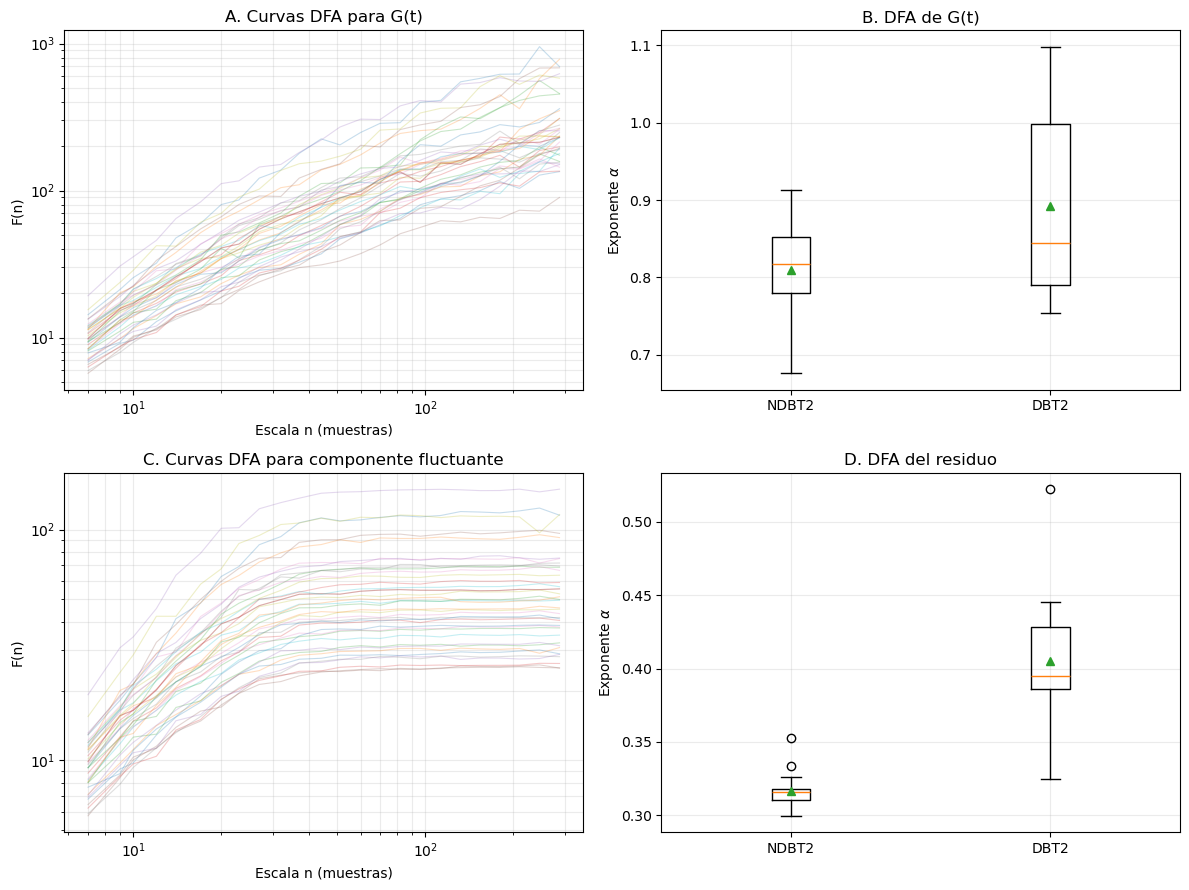

In [7]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from common_cap3 import load_subjects, savgol_trend, dfa_alpha, N_12_DAYS

BASE_DIR = Path('.').resolve()
OUT_DIR = BASE_DIR / 'figuras_cap3'
OUT_DIR.mkdir(exist_ok=True)
subjects = load_subjects(base_dir=BASE_DIR, n_points=N_12_DAYS)

rows = []
curves_G = {'NDBT2': [], 'DBT2': []}
curves_r = {'NDBT2': [], 'DBT2': []}
for grupo, data in subjects.items():
    for sid, G in data.items():
        trend = savgol_trend(G, window=51, polyorder=3)
        r = G - trend
        aG, scalesG, FG, _ = dfa_alpha(G, order=1)
        ar, scalesr, Fr, _ = dfa_alpha(r, order=1)
        rows.append({'grupo': grupo, 'sujeto': sid, 'alpha_G': aG, 'alpha_residuo': ar})
        curves_G[grupo].append((scalesG, FG))
        curves_r[grupo].append((scalesr, Fr))
res = pd.DataFrame(rows)
print(res)
print(res.groupby('grupo')[['alpha_G', 'alpha_residuo']].agg(['mean','std','count']))

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for grupo in ['NDBT2', 'DBT2']:
    for sc, F in curves_G[grupo]:
        axes[0, 0].loglog(sc, F, alpha=0.25, linewidth=0.8)
    for sc, F in curves_r[grupo]:
        axes[1, 0].loglog(sc, F, alpha=0.25, linewidth=0.8)

for ax, col, title in [(axes[0, 1], 'alpha_G', 'B. DFA de G(t)'), (axes[1, 1], 'alpha_residuo', 'D. DFA del residuo')]:
    vals_s = res.loc[res.grupo == 'NDBT2', col].dropna()
    vals_e = res.loc[res.grupo == 'DBT2', col].dropna()
    ax.boxplot([vals_s, vals_e], labels=['NDBT2', 'DBT2'], showmeans=True)
    ax.set_ylabel(r'Exponente $\alpha$')
    ax.set_title(title)
    ax.grid(alpha=0.25)

axes[0, 0].set_title('A. Curvas DFA para G(t)')
axes[0, 0].set_xlabel('Escala n (muestras)')
axes[0, 0].set_ylabel('F(n)')
axes[0, 0].grid(alpha=0.25, which='both')
axes[1, 0].set_title('C. Curvas DFA para componente fluctuante')
axes[1, 0].set_xlabel('Escala n (muestras)')
axes[1, 0].set_ylabel('F(n)')
axes[1, 0].grid(alpha=0.25, which='both')
plt.tight_layout()
plt.savefig(OUT_DIR / 'figura_3_1_4_dfa.png', dpi=300)
plt.show()


## 3 2 1 velocidad acondicionada

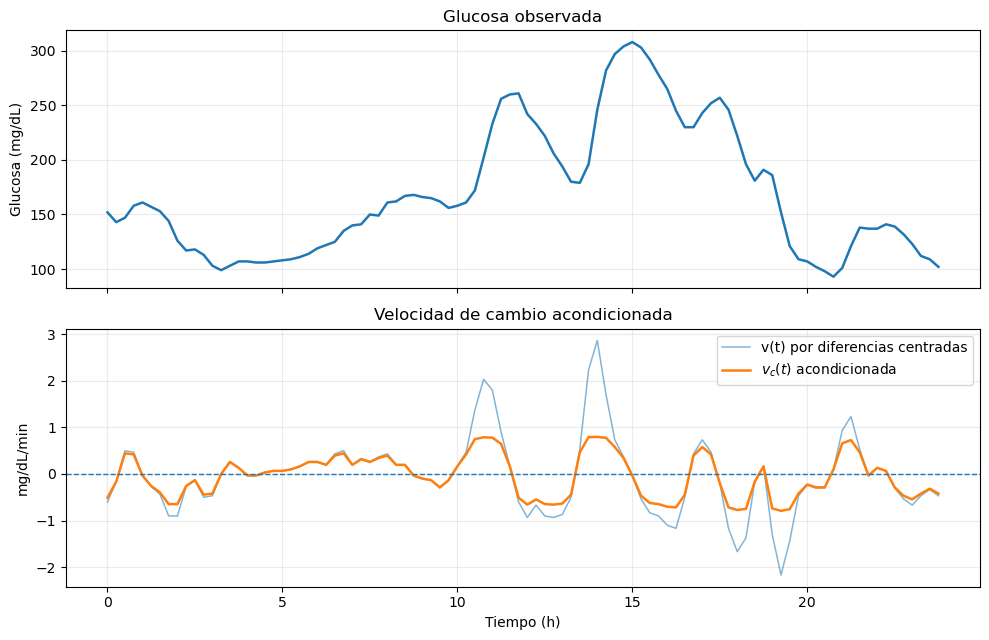

In [8]:
from pathlib import Path
import matplotlib.pyplot as plt
from common_cap3 import load_subjects, day_slice, time_axis, centered_velocity, conditioned_velocity, N_12_DAYS

BASE_DIR = Path('.').resolve()
OUT_DIR = BASE_DIR / 'figuras_cap3'
OUT_DIR.mkdir(exist_ok=True)
subjects = load_subjects(base_dir=BASE_DIR, n_points=N_12_DAYS)

grupo = 'DBT2'
sujeto = 5
dia = 0
G = subjects[grupo][sujeto][day_slice(dia, 0, 24)]
v = centered_velocity(G)
vc = conditioned_velocity(v, kappa=1.0)
t = time_axis(len(G), unit='hours')

fig, axes = plt.subplots(2, 1, figsize=(10, 6.5), sharex=True)
axes[0].plot(t, G, linewidth=1.8)
axes[0].set_ylabel('Glucosa (mg/dL)')
axes[0].set_title('Glucosa observada')
axes[0].grid(alpha=0.25)

axes[1].plot(t, v, linewidth=1.1, alpha=0.55, label='v(t) por diferencias centradas')
axes[1].plot(t, vc, linewidth=1.8, label=r'$v_c(t)$ acondicionada')
axes[1].axhline(0, linestyle='--', linewidth=1)
axes[1].set_xlabel('Tiempo (h)')
axes[1].set_ylabel('mg/dL/min')
axes[1].set_title('Velocidad de cambio acondicionada')
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.savefig(OUT_DIR / 'figura_3_2_1_velocidad_acondicionada.png', dpi=300)
plt.show()


## 3 2 3 energia local DCT

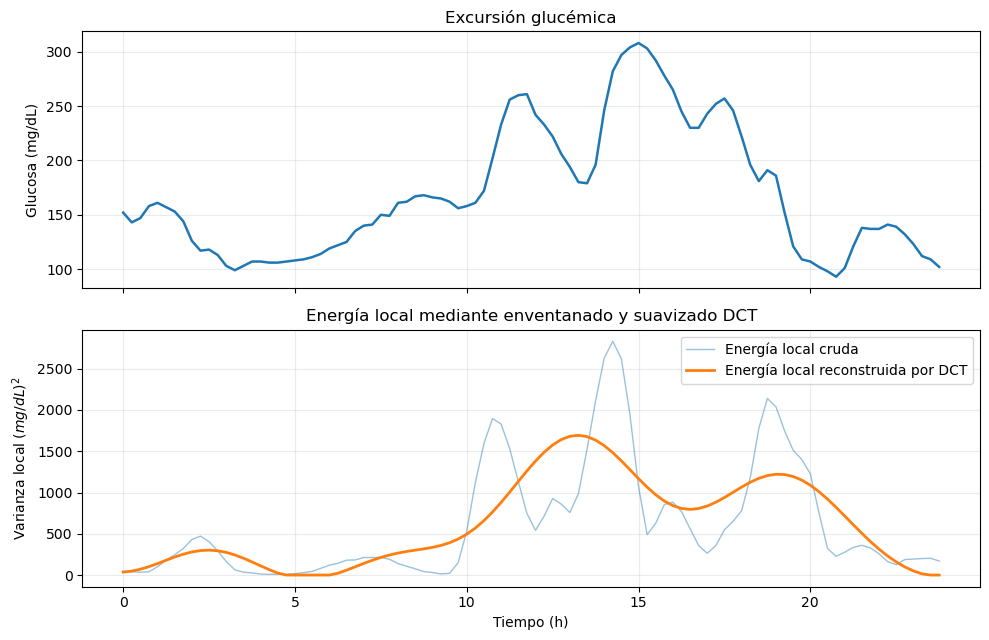

In [9]:
from pathlib import Path
import matplotlib.pyplot as plt
from common_cap3 import load_subjects, day_slice, time_axis, local_energy, dct_smooth_energy, N_12_DAYS

BASE_DIR = Path('.').resolve()
OUT_DIR = BASE_DIR / 'figuras_cap3'
OUT_DIR.mkdir(exist_ok=True)
subjects = load_subjects(base_dir=BASE_DIR, n_points=N_12_DAYS)

grupo = 'DBT2'
sujeto = 5
dia = 0
G = subjects[grupo][sujeto][day_slice(dia, 0, 24)]
E = local_energy(G, window=10)
E_s = dct_smooth_energy(E, keep_fraction=0.10)
t = time_axis(len(G), unit='hours')

fig, axes = plt.subplots(2, 1, figsize=(10, 6.5), sharex=True)
axes[0].plot(t, G, linewidth=1.8)
axes[0].set_ylabel('Glucosa (mg/dL)')
axes[0].set_title('Excursión glucémica')
axes[0].grid(alpha=0.25)

axes[1].plot(t, E, linewidth=1.0, alpha=0.45, label='Energía local cruda')
axes[1].plot(t, E_s, linewidth=2.0, label='Energía local reconstruida por DCT')
axes[1].set_xlabel('Tiempo (h)')
axes[1].set_ylabel(r'Varianza local $(mg/dL)^2$')
axes[1].set_title('Energía local mediante enventanado y suavizado DCT')
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.savefig(OUT_DIR / 'figura_3_2_3_energia_local_DCT.png', dpi=300)
plt.show()


## 3 2 4 indicador S t

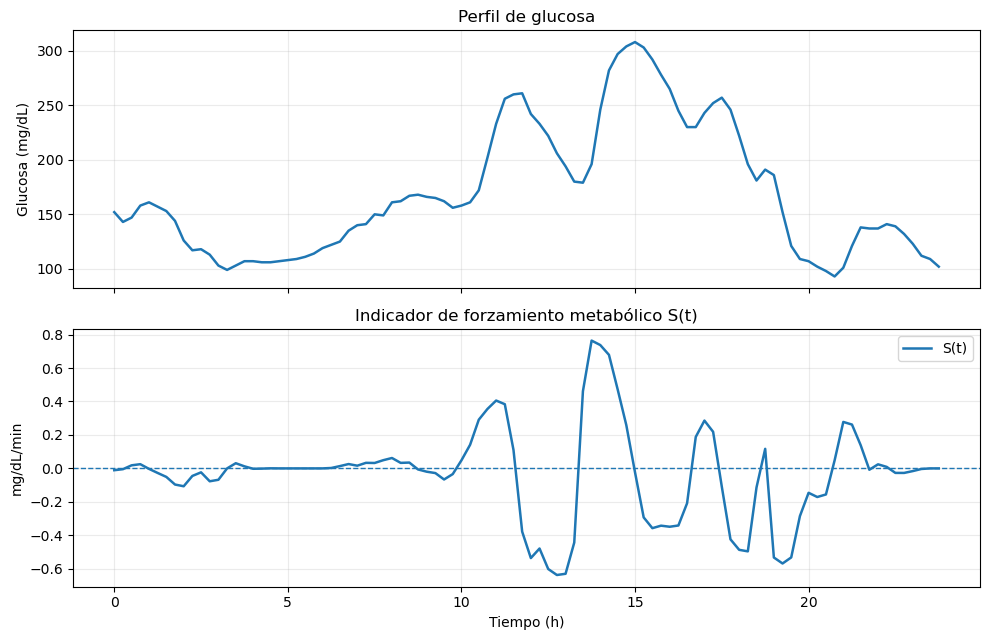

In [10]:
from pathlib import Path
import matplotlib.pyplot as plt
from common_cap3 import load_subjects, day_slice, time_axis, metabolic_force, N_12_DAYS

BASE_DIR = Path('.').resolve()
OUT_DIR = BASE_DIR / 'figuras_cap3'
OUT_DIR.mkdir(exist_ok=True)
subjects = load_subjects(base_dir=BASE_DIR, n_points=N_12_DAYS)

grupo = 'DBT2'
sujeto = 5
dia = 0
G = subjects[grupo][sujeto][day_slice(dia, 0, 24)]
res = metabolic_force(G, window_energy=10, keep_fraction=0.10, kappa=1.0, formula='vc_times_Ehat')
S = res['S']
t = time_axis(len(G), unit='hours')

fig, axes = plt.subplots(2, 1, figsize=(10, 6.5), sharex=True)
axes[0].plot(t, G, linewidth=1.8)
axes[0].set_ylabel('Glucosa (mg/dL)')
axes[0].set_title('Perfil de glucosa')
axes[0].grid(alpha=0.25)

axes[1].plot(t, S, linewidth=1.8, label='S(t)')
axes[1].axhline(0, linestyle='--', linewidth=1)
axes[1].set_xlabel('Tiempo (h)')
axes[1].set_ylabel('mg/dL/min')
axes[1].set_title('Indicador de forzamiento metabólico S(t)')
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.savefig(OUT_DIR / 'figura_3_2_4_indicador_S_t.png', dpi=300)
plt.show()


## 3 2 5 PSD S t

    grupo  sujeto  beta_baja_0_5_4_ciclos_dia  beta_alta_12_40_ciclos_dia
0   NDBT2       1                   -1.037212                    3.639464
1   NDBT2       2                   -1.312750                    2.753331
2   NDBT2       3                   -1.082565                    2.956152
3   NDBT2       4                   -0.258538                    3.212918
4   NDBT2       5                   -1.259257                    2.307243
5   NDBT2       6                   -1.269473                    3.452620
6   NDBT2       7                   -0.772191                    3.235694
7   NDBT2       8                   -0.915024                    3.215955
8   NDBT2       9                   -1.071740                    3.050920
9   NDBT2      10                   -1.069306                    3.372831
10  NDBT2      11                   -1.218645                    2.312815
11  NDBT2      12                   -0.876222                    3.229197
12  NDBT2      13                   -0

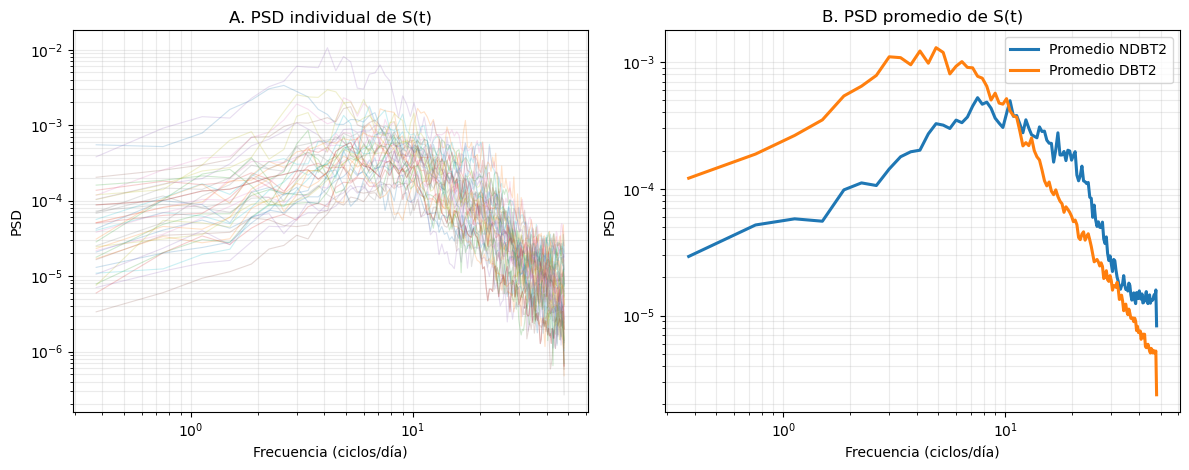

In [11]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from common_cap3 import load_subjects, metabolic_force, colored_noise_beta, N_12_DAYS

BASE_DIR = Path('.').resolve()
OUT_DIR = BASE_DIR / 'figuras_cap3'
OUT_DIR.mkdir(exist_ok=True)
subjects = load_subjects(base_dir=BASE_DIR, n_points=N_12_DAYS)

rows = []
psd = {'NDBT2': [], 'DBT2': []}
for grupo, data in subjects.items():
    for sid, G in data.items():
        S = metabolic_force(G, formula='vc_times_Ehat')['S']
        beta_low, f, pxx, _ = colored_noise_beta(S, fit_range=(0.5, 4.0))
        beta_high, _, _, _ = colored_noise_beta(S, fit_range=(12.0, 40.0))
        rows.append({'grupo': grupo, 'sujeto': sid, 'beta_baja_0_5_4_ciclos_dia': beta_low, 'beta_alta_12_40_ciclos_dia': beta_high})
        psd[grupo].append((f, pxx))
res = pd.DataFrame(rows)
print(res)
print(res.groupby('grupo')[['beta_baja_0_5_4_ciclos_dia', 'beta_alta_12_40_ciclos_dia']].agg(['mean','std','count']))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for grupo in ['NDBT2', 'DBT2']:
    curves = []
    f_ref = None
    for f, pxx in psd[grupo]:
        mask = (f > 0) & (pxx > 0)
        axes[0].loglog(f[mask], pxx[mask], alpha=0.22, linewidth=0.8)
        if f_ref is None:
            f_ref = f
        curves.append(pxx)
    if curves:
        mean_pxx = np.nanmean(np.vstack(curves), axis=0)
        mask = (f_ref > 0) & (mean_pxx > 0)
        axes[1].loglog(f_ref[mask], mean_pxx[mask], linewidth=2.2, label=f'Promedio {grupo}')

axes[0].set_title('A. PSD individual de S(t)')
axes[1].set_title('B. PSD promedio de S(t)')
for ax in axes:
    ax.set_xlabel('Frecuencia (ciclos/día)')
    ax.set_ylabel('PSD')
    ax.grid(alpha=0.25, which='both')
axes[1].legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'figura_3_2_5_PSD_S_t.png', dpi=300)
plt.show()


## 3 2 6 wavelet alba ingestas

Fenómeno del alba
    dia  inicio_h  fin_h  DeltaG       I_G       I_S   W_lenta clasificacion
0     1       3.0    8.0    46.0  0.974110  0.549047  0.008124       Posible
1     2       3.0    8.0    59.0  0.942029  0.945700  0.009744       Posible
2     3       3.0    8.0    98.0  0.835777  0.578419  0.077424       Posible
3     4       3.0    8.0   152.0  1.000000  1.000000  0.136066       Posible
4     5       3.0    8.0    62.0 -0.078049  0.521047  0.074735       Posible
5     6       3.0    8.0    32.0  0.972851  0.820562  0.096592       Posible
6     7       3.0    8.0    26.0  0.794872  0.988394  0.031818       Posible
7     8       3.0    8.0   146.0  1.000000  0.839151  0.107090       Posible
8     9       3.0    8.0   123.0  1.000000  0.993865  0.050807       Posible
9    10       3.0    8.0    46.0  0.988372  0.193832  0.129730       Posible
10   11       3.0    8.0    52.0  0.918465  0.783659  0.057828       Posible
11   12       3.0    8.0    17.0 -0.554610  0.212583  0.18

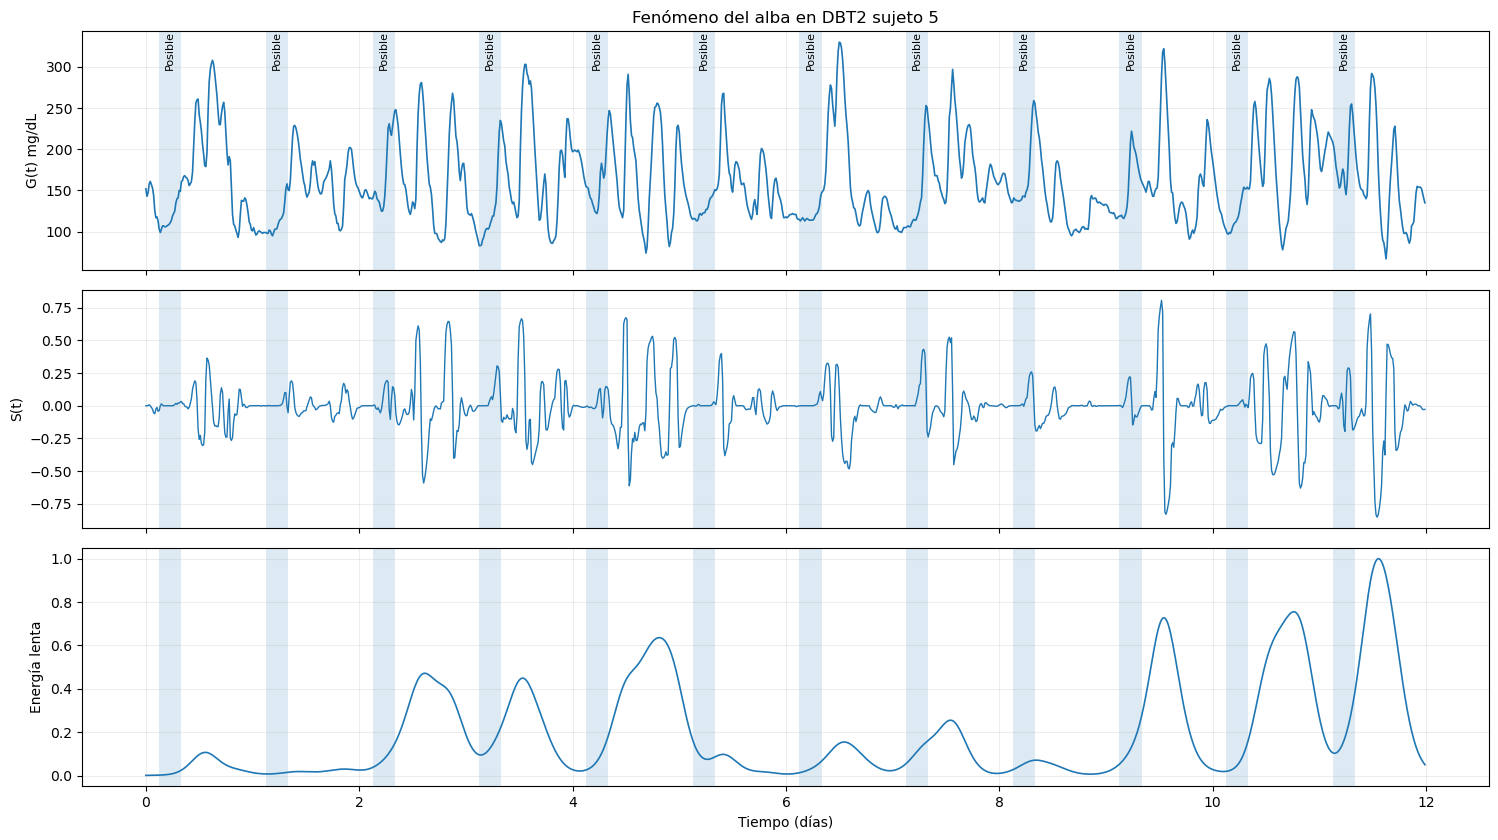

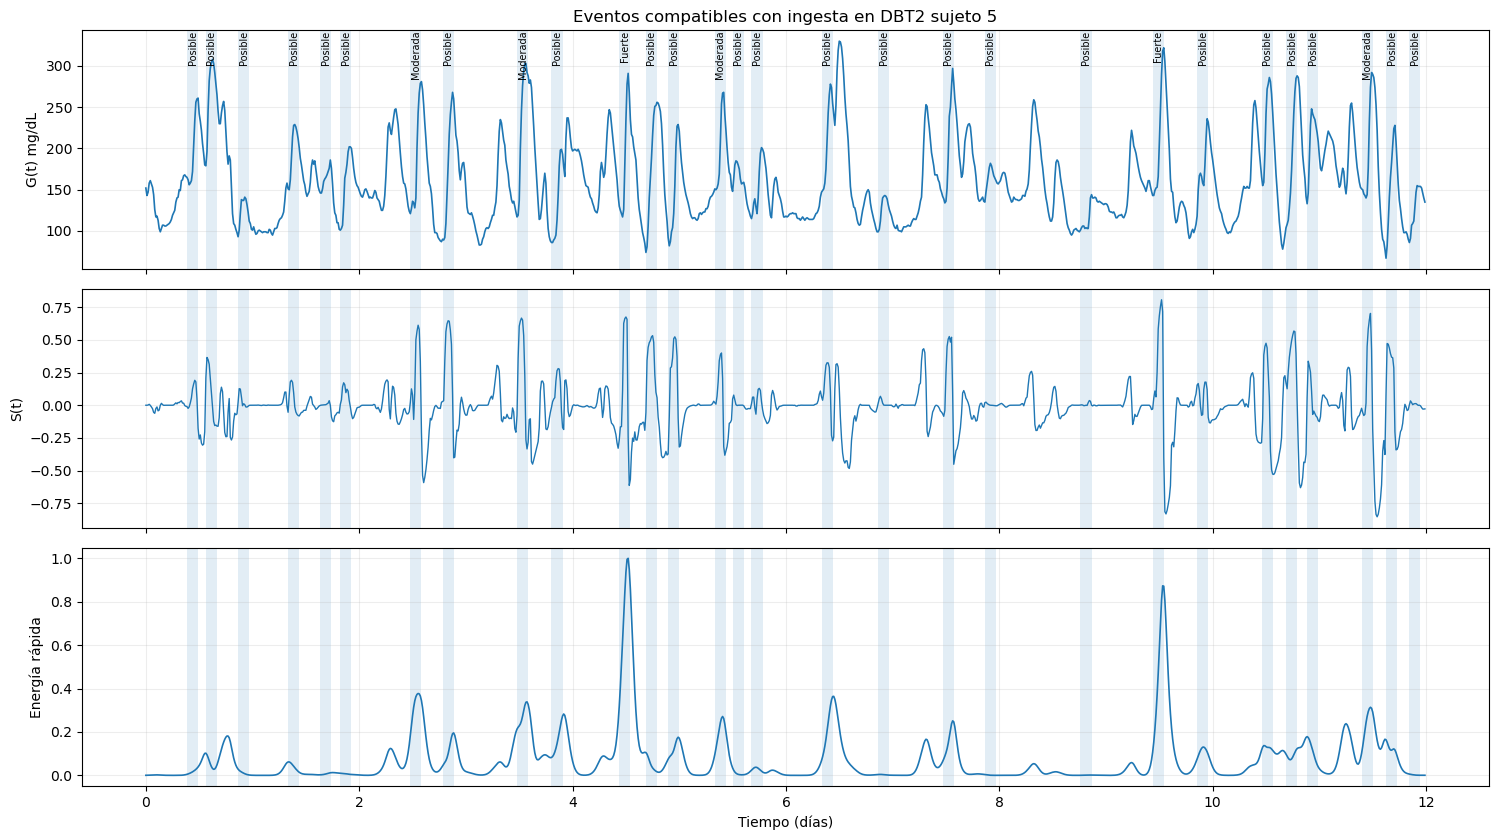

In [12]:
from pathlib import Path
import matplotlib.pyplot as plt
from common_cap3 import (
    load_subjects, metabolic_force, morlet_band_energy, detect_dawn,
    detect_meal_like_events, time_axis, FS_PER_DAY, N_12_DAYS
)

BASE_DIR = Path('.').resolve()
OUT_DIR = BASE_DIR / 'figuras_cap3'
OUT_DIR.mkdir(exist_ok=True)
subjects = load_subjects(base_dir=BASE_DIR, n_points=N_12_DAYS)

# Sujeto representativo usado para alba/ingestas. Cambiar a NDBT2 si corresponde al documento final.
grupo = 'DBT2'
sujeto = 5
G = subjects[grupo][sujeto]
S = metabolic_force(G, formula='vc_times_Ehat')['S']
t_days = time_axis(len(G), unit='days')

slow_energy, _, _ = morlet_band_energy(S, (3.0, 8.0))
fast_energy, _, _ = morlet_band_energy(S, (0.5, 2.0))
dawn = detect_dawn(G, S)
# min_score=15 reproduce 29 ventanas no solapadas para DBT2 sujeto 5 con estos datos y esta implementación.
meals = detect_meal_like_events(G, S, window_samples=10, min_delta_g=20, min_score=15)
print('Fenómeno del alba')
print(dawn)
print('\nEventos compatibles con ingesta')
print(meals)
print('\nConteo ingestas por clasificación')
print(meals['clasificacion'].value_counts() if not meals.empty else 'Sin eventos')
if grupo == 'DBT2' and sujeto == 5 and len(meals) != 29:
    print('ATENCIÓN: el texto menciona 29 ventanas; revisar fórmula exacta de S(t), umbrales y score si este número cambia.')

# Figura alba: 12 días continuos, G(t), S(t), energía wavelet lenta.
fig, axes = plt.subplots(3, 1, figsize=(15, 8.5), sharex=True)
axes[0].plot(t_days, G, linewidth=1.2)
axes[1].plot(t_days, S, linewidth=1.0)
axes[2].plot(t_days, slow_energy, linewidth=1.2)
axes[0].set_ylabel('G(t) mg/dL')
axes[1].set_ylabel('S(t)')
axes[2].set_ylabel('Energía lenta')
axes[2].set_xlabel('Tiempo (días)')
for ax in axes:
    ax.grid(alpha=0.22)
for _, row in dawn.iterrows():
    start = (row['dia'] - 1) + row['inicio_h'] / 24
    end = (row['dia'] - 1) + row['fin_h'] / 24
    for ax in axes:
        ax.axvspan(start, end, alpha=0.15)
    axes[0].text((start + end) / 2, axes[0].get_ylim()[1], row['clasificacion'], ha='center', va='top', fontsize=8, rotation=90)
axes[0].set_title(f'Fenómeno del alba en {grupo} sujeto {sujeto}')
plt.tight_layout()
plt.savefig(OUT_DIR / 'figura_3_2_6_1_alba_sujeto_5.png', dpi=300)
plt.show()

# Figura ingestas: 12 días continuos, G(t), S(t), energía wavelet rápida.
fig, axes = plt.subplots(3, 1, figsize=(15, 8.5), sharex=True)
axes[0].plot(t_days, G, linewidth=1.2)
axes[1].plot(t_days, S, linewidth=1.0)
axes[2].plot(t_days, fast_energy, linewidth=1.2)
axes[0].set_ylabel('G(t) mg/dL')
axes[1].set_ylabel('S(t)')
axes[2].set_ylabel('Energía rápida')
axes[2].set_xlabel('Tiempo (días)')
for ax in axes:
    ax.grid(alpha=0.22)
for _, row in meals.iterrows():
    start = row['inicio_idx'] / FS_PER_DAY
    end = row['fin_idx'] / FS_PER_DAY
    for ax in axes:
        ax.axvspan(start, end, alpha=0.13)
    axes[0].text((start + end) / 2, axes[0].get_ylim()[1], row['clasificacion'], ha='center', va='top', fontsize=7, rotation=90)
axes[0].set_title(f'Eventos compatibles con ingesta en {grupo} sujeto {sujeto}')
plt.tight_layout()
plt.savefig(OUT_DIR / 'figura_3_2_6_3_ingestas_sujeto_5.png', dpi=300)
plt.show()


## 3 3 lyapunov nolds rosenstein

In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from common_cap3 import load_subjects, lyapunov_rosenstein, N_12_DAYS

BASE_DIR = Path('.').resolve()
OUT_DIR = BASE_DIR / 'figuras_cap3'
OUT_DIR.mkdir(exist_ok=True)
subjects = load_subjects(base_dir=BASE_DIR, n_points=N_12_DAYS)

rows = []
example_curve = None
for grupo, data in subjects.items():
    for sid, G in data.items():
        lam, TL, t_h, logd = lyapunov_rosenstein(G, m=4, tau=4, min_tsep=96, max_k=40, fit_k=(1, 12))
        rows.append({'grupo': grupo, 'sujeto': sid, 'lambda_h_inv': lam, 'T_L_horas': TL})
        if grupo == 'DBT2' and sid == 5:
            example_curve = (t_h, logd, lam)
res = pd.DataFrame(rows)
print(res)
print(res.groupby('grupo')[['lambda_h_inv', 'T_L_horas']].agg(['mean','std','count']))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
if example_curve is not None:
    t_h, logd, lam = example_curve
    axes[0].plot(t_h, logd, marker='o', markersize=3, linewidth=1.2)
    axes[0].set_title(fr'Divergencia media: $\lambda={lam:.3f}$ h$^{{-1}}$')
    axes[0].set_xlabel('Tiempo de evolución (h)')
    axes[0].set_ylabel(r'$\langle \ln d(k) \rangle$')
    axes[0].grid(alpha=0.25)

vals_s = res.loc[res.grupo == 'NDBT2', 'lambda_h_inv'].dropna()
vals_e = res.loc[res.grupo == 'DBT2', 'lambda_h_inv'].dropna()
axes[1].boxplot([vals_s, vals_e], labels=['NDBT2', 'DBT2'], showmeans=True)
axes[1].set_ylabel(r'$\lambda$ (h$^{-1}$)')
axes[1].set_title('Exponente máximo de Lyapunov por grupo')
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.savefig(OUT_DIR / 'figura_3_3_lyapunov.png', dpi=300)
plt.show()


## 3 4 HxC

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from common_cap3 import load_subjects, permutation_distribution, h_complexity, hx_c_bounds, N_12_DAYS

BASE_DIR = Path('.').resolve()
OUT_DIR = BASE_DIR / 'figuras_cap3'
OUT_DIR.mkdir(exist_ok=True)
subjects = load_subjects(base_dir=BASE_DIR, n_points=N_12_DAYS)

rows = []
for grupo, data in subjects.items():
    for sid, G in data.items():
        p = permutation_distribution(G, D=3, tau=1)
        H, C = h_complexity(p)
        rows.append({'grupo': grupo, 'sujeto': sid, 'H': H, 'C': C})
res = pd.DataFrame(rows)
print(res)
print(res.groupby('grupo')[['H','C']].agg(['mean','std','count']))
centroids = res.groupby('grupo')[['H','C']].mean()
print('\nCentroides:')
print(centroids)

Hgrid, Cmin, Cmax = hx_c_bounds(M=6, n_random=30000, seed=123)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax in axes:
    ax.plot(Hgrid, Cmin, linewidth=1.2, label=r'$C_{min}$ aprox.')
    ax.plot(Hgrid, Cmax, linewidth=1.2, label=r'$C_{max}$ aprox.')
    for grupo, marker in [('NDBT2', 'o'), ('DBT2', 's')]:
        sub = res[res.grupo == grupo]
        ax.scatter(sub['H'], sub['C'], marker=marker, s=45, label=grupo, alpha=0.85)
    ax.scatter(centroids.loc['NDBT2','H'], centroids.loc['NDBT2','C'], s=140, marker='X', label='Centroide NDBT2')
    ax.scatter(centroids.loc['DBT2','H'], centroids.loc['DBT2','C'], s=140, marker='X', label='Centroide DBT2')
    ax.set_xlabel('Entropía normalizada H')
    ax.set_ylabel('Complejidad estadística C')
    ax.grid(alpha=0.25)
axes[0].set_title('A. Plano H×C global')
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, max(np.nanmax(Cmax), res.C.max()) * 1.1)
axes[1].set_title('B. Ampliación de zona de interés')
axes[1].set_xlim(0.7, 1.0)
axes[1].set_ylim(0, 0.22)
axes[1].legend(loc='best', fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / 'figura_3_4_HxC.png', dpi=300)
plt.show()


## 3 4 OPTM Stat MS

In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from common_cap3 import load_subjects, optm_stationary_indicator, classify_stat_ms, N_12_DAYS

BASE_DIR = Path('.').resolve()
OUT_DIR = BASE_DIR / 'figuras_cap3'
OUT_DIR.mkdir(exist_ok=True)
subjects = load_subjects(base_dir=BASE_DIR, n_points=N_12_DAYS)

rows = []
for grupo, data in subjects.items():
    for sid, G in data.items():
        stat_ms, P, vS = optm_stationary_indicator(G, D=3, tau=1)
        rows.append({'grupo': grupo, 'sujeto': sid, 'Stat_MS': stat_ms, 'diagnostico_por_umbral': classify_stat_ms(stat_ms)})
res = pd.DataFrame(rows).sort_values(['grupo','sujeto'])
print(res)

# Tabla pivote similar a la del documento.
pivot = res.pivot(index='sujeto', columns='grupo', values='Stat_MS')
print('\nTabla Stat_MS por sujeto:')
print(pivot)

fig, ax = plt.subplots(figsize=(10, 4.8))
for grupo, marker in [('NDBT2', 'o'), ('DBT2', 's')]:
    sub = res[res.grupo == grupo]
    ax.scatter(sub['sujeto'], sub['Stat_MS'], marker=marker, s=45, label=grupo)
ax.axhline(0.49, linestyle='--', linewidth=1, label='Umbral sano/dudoso')
ax.axhline(0.505, linestyle='--', linewidth=1, label='Umbral dudoso/diabetes')
ax.set_xlabel('Sujeto')
ax.set_ylabel(r'$||v_S||$')
ax.set_title('Indicador OPTM basado en vector estacionario')
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'figura_3_4_OPTM_Stat_MS.png', dpi=300)
plt.show()


## 3 5 embedding AMI FNN espacio fase

In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
from common_cap3 import (
    load_subjects, average_mutual_information, false_nearest_neighbors,
    delay_embed, N_12_DAYS
)

BASE_DIR = Path('.').resolve()
OUT_DIR = BASE_DIR / 'figuras_cap3'
OUT_DIR.mkdir(exist_ok=True)
subjects = load_subjects(base_dir=BASE_DIR, n_points=N_12_DAYS)

sujeto_ndbt2 = 1
sujeto_dbt2 = 5
G_s = subjects['NDBT2'][sujeto_ndbt2]
G_e = subjects['DBT2'][sujeto_dbt2]

fig, axes = plt.subplots(2, 3, figsize=(15, 8.5))
for G, grupo, col in [(G_s, 'NDBT2', 0), (G_e, 'DBT2', 1)]:
    lags, ami = average_mutual_information(G, max_lag=32, n_bins=16)
    axes[0, 0].plot(lags, ami, marker='o', markersize=3, linewidth=1.2, label=grupo)
    axes[0, 1].plot(lags[1:], -1 * (ami[1:] - ami[:-1]), marker='o', markersize=3, linewidth=1.2, label=grupo)
    ms, fnn = false_nearest_neighbors(G, tau=4, max_m=8)
    axes[0, 2].plot(ms, fnn, marker='o', markersize=4, linewidth=1.2, label=grupo)

axes[0, 0].set_title('A. AMI normalizada')
axes[0, 0].set_xlabel(r'$\tau_{emb}$ (muestras)')
axes[0, 0].set_ylabel('AMI normalizada')
axes[0, 1].set_title('B. Pérdida discreta de información')
axes[0, 1].set_xlabel(r'$\tau_{emb}$ (muestras)')
axes[0, 1].set_ylabel(r'$-\Delta$ AMI')
axes[0, 2].set_title('C. Falsos vecinos cercanos')
axes[0, 2].set_xlabel(r'$m_{emb}$')
axes[0, 2].set_ylabel('FNN (%)')
axes[0, 2].axhline(5, linestyle='--', linewidth=1)
for ax in axes[0, :]:
    ax.grid(alpha=0.25)
    ax.legend()

# Proyección 2D con tau_emb=4 para cada grupo.
for ax, G, title in [(axes[1, 0], G_s, f'D. Fase NDBT2 sujeto {sujeto_ndbt2}'), (axes[1, 1], G_e, f'E. Fase DBT2 sujeto {sujeto_dbt2}')]:
    tau = 4
    x0 = G[:-tau]
    x1 = G[tau:]
    ax.scatter(x0, x1, s=10, alpha=0.55)
    lim_min = min(x0.min(), x1.min())
    lim_max = max(x0.max(), x1.max())
    ax.plot([lim_min, lim_max], [lim_min, lim_max], linestyle='--', linewidth=1)
    ax.set_xlabel(r'$G_t$ (mg/dL)')
    ax.set_ylabel(r'$G_{t+\tau}$ (mg/dL)')
    ax.set_title(title)
    ax.grid(alpha=0.25)

# Proyección 3D simple del sujeto DBT2.
axes[1, 2].axis('off')
fig.delaxes(axes[1, 2])
ax3 = fig.add_subplot(2, 3, 6, projection='3d')
Y = delay_embed(G_e, m=3, tau=4)
ax3.plot(Y[:, 0], Y[:, 1], Y[:, 2], linewidth=0.7, alpha=0.75)
ax3.set_xlabel(r'$G_t$')
ax3.set_ylabel(r'$G_{t+\tau}$')
ax3.set_zlabel(r'$G_{t+2\tau}$')
ax3.set_title('F. Proyección 3D del embedding')

plt.tight_layout()
plt.savefig(OUT_DIR / 'figura_3_5_embedding_AMI_FNN_fase.png', dpi=300)
plt.show()
